### CNN 활용 - 1 : Pipeline

tf.data + ImageDataGenerator
### Numpy VS Tensor 
- 장단점을 이해해야함
- 데이터가 커지면 속도가 중요함
### Numpy
- 다른 프레임 워크에서와의 호환성
- Numpy는 modern 하지못함
- 현대적 CPU 동시 사용하지만 scheduling을 효율적으로 사용하지 못함(idle time)
- 데이터 규모가 커지면 속도측면에서 비효율적 
예. ImageNet 데이터 사용시 몇 주 동안 학습 시켜야함 

### Tensor 
- 데이터 파이프라인 구축
  - 파이프라인 : 데이터 로드부터 머신러닝 모델을 거쳐 결과까지 나오는 하나의 연속된 흐름
  - 현대적인 모든 머신러닝 프레임워크에 존재함 (Scikit, TensorFlow)
  -  홀드아웃 , 다양한 데이터 증강 가능 제공
    - 빠르고 메모리 많이 필요함(하드웨어)

### Pipeline
- column에 따라서 분기를 할수 없어서 ColumnTransformer 를 조건문을 이용해서 특정 조건에 맞으면 가능하도록함
- 데이터 or ML pipeline (데이터가 입력부터 모델 학습 까지의 전체 흐름)
  -  Orange3, Rapidminer , Azure에서 drag&drop형식으로 pipeline 만들수 있어서 강력함(코드 불필요)
  -  Scikit-learn : 전체 자동화가 가능하고 다양한 테스트를 동시에 여러개 가능 
  https://zephyrus1111.tistory.com/254
  
  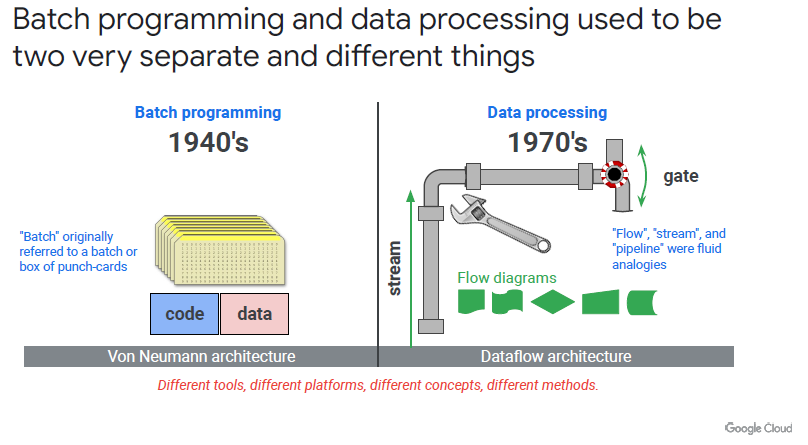
  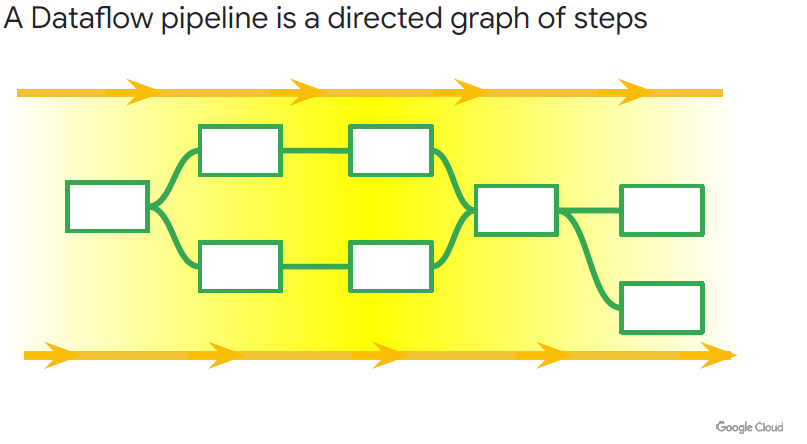

In [1]:
# !pip install scikit-learn

In [1]:
from sklearn.pipeline import Pipeline,make_pipeline
# from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import MinMaxScaler

In [2]:
from sklearn.datasets import load_iris
data = load_iris()

하나의 연속적 흐름으로 여기고 관리함

In [3]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [4]:
# 'std' → 단계 이름(label)
# MinMaxScaler() → 실제 실행 객체
pipeline = Pipeline([(('std'),MinMaxScaler()),(('knn'),KNeighborsClassifier())])
pipeline

,steps,"[('std', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [5]:
type(pipeline)

sklearn.pipeline.Pipeline

In [6]:
vars(pipeline)  # 객체(object)의 내부 속성(attribute)들을 딕셔너리 형태로 보여주는 함수

{'steps': [('std', MinMaxScaler()), ('knn', KNeighborsClassifier())],
 'transform_input': None,
 'memory': None,
 'verbose': False}

In [7]:
pipeline.fit(data.data,data.target) # 두 가지를 한번에 처리됨 

,steps,"[('std', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [8]:
vars(pipeline)

{'steps': [('std', MinMaxScaler()), ('knn', KNeighborsClassifier())],
 'transform_input': None,
 'memory': None,
 'verbose': False}

In [9]:
pipeline.predict(data.data)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## building data pipelines with tf.data
- 이미지 로드 참고 : https://www.tensorflow.org/tutorials/load_data/images?hl=ko
  - ML에서는 데이터가 항상 부족함
    - shuffled(일반성 보장을 위해서 섞음)
    - batched (전체 데이터를 한번에 사용하지 않고 일부 사용해서 업데이트)
      - 문제 풀때 한단원 보고 답 보는지 아니면 한문제 풀고 답 확인 하는지 (후자는 학습은 느려지지만 정확도는 높음)
      - batch size :NFL!!
    - **batches to be available before the current epoch is finished**
      - 실무에서 batch 구성에 시간이 걸리기 때문에 CPU,GPU 시간을 smooth하게 연결하도록 미리 준비해두어 단축시킴

## tf.data
  - tf.data는 영상 데이터 뿐 아니라 pandas, 영상,음성, 자연어 모두 가능한 범용적인 데이터
  - tensorflow에서 데이터 처리할때 쉽고 빠름
  - 데이터 규모가 커질떄 유용
1. scalability 
  - 확장 가능하도록 만들어놓아서 일관성 확보(우아함)
   > tf 의 복잡성 : 모델 만드는 방법 5가지
2. Simple
3. Reusable
  - 재사용 가능 
4. Dynamic
  - 간단한 문법으로 유동적으로 다양한 경우 대비
  - 원하는 기법을 만들어서 사용 가능

In [10]:
import tensorflow as tf

In [11]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [12]:
image_dataset_from_directory

<function keras.utils.image_dataset.image_dataset_from_directory(directory, labels='inferred', label_mode='int', class_names=None, color_mode='rgb', batch_size=32, image_size=(256, 256), shuffle=True, seed=None, validation_split=None, subset=None, interpolation='bilinear', follow_links=False, crop_to_aspect_ratio=False, **kwargs)>

In [13]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

In [14]:
X_train  # Numpy format - data 파이프라인을 거쳐야함 

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

Numpy, Pandas,Tensorflow 의 from
-  어떤 객체를 기반으로 다른 형태로 변경해줌

train, test 데이터 묶어서 관리하며 데이터세트로부터 상속 받음

*  `tf.data.Dataset.from_tensor_slices( tensors)`
  - keras에서 내부적으로 하나씩 추출하기 좋아 실무에서 많이씀 
  - input_shape 에서도 이와 같이 맞췄었음
*  `tf.data.Dataset.from_tensors(tensors)`

In [15]:
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices
# Slicing a 1D tensor produces scalar tensor elements.
dataset = tf.data.Dataset.from_tensor_slices([1,2,3])
dataset

<TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [16]:
# dir(dataset)

In [17]:
list(dataset.as_numpy_iterator())  

[1, 2, 3]

In [18]:
# Slicing a 2D tensor produces 1D tensor elements.
dataset = tf.data.Dataset.from_tensor_slices([[1,2],[3,4]])
list(dataset.as_numpy_iterator())

[array([1, 2]), array([3, 4])]

In [19]:
# Slicing a tuple of 1D tensors produces tuple elements containing
# scalar tensors.
dataset = tf.data.Dataset.from_tensor_slices(([1, 2], [3, 4], [5, 6]))
list(dataset.as_numpy_iterator())

[(1, 3, 5), (2, 4, 6)]

In [20]:
# Dictionary structure is also preserved.
dataset = tf.data.Dataset.from_tensor_slices({"a": [1, 2], "b": [3, 4]})
list(dataset.as_numpy_iterator())

[{'a': 1, 'b': 3}, {'a': 2, 'b': 4}]

In [21]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [22]:
ts = tf.data.Dataset.from_tensor_slices((X_train,y_train))
ts  # 28x28 image 1개와 스칼라 값 label 1개로 생성

<TensorSliceDataset element_spec=(TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.uint8, name=None))>

In [23]:
len(ts)  # 데이터가 60000

60000

In [24]:
ts2 = tf.data.Dataset.from_tensors((X_train,y_train))
ts2  # 28x28 image  & label가 60,000개
# from_tensors단일 요소만 포함하는 데이터 세트를 생성, 입력 텐서를 여러 요소로 슬라이스하려면 from_tensor_slices사용
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensors

<TensorDataset element_spec=(TensorSpec(shape=(60000, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(60000,), dtype=tf.uint8, name=None))>

In [25]:
len(ts2) # 전체 1개로

1

In [26]:
set(dir(ts)) ^ set(dir(ts2)) # 기능의 차이 없음

set()

In [27]:
dir(ts) #__iter_,apply, cache, map, filter, reduce, shuffle, zip ...

['_GeneratorState',
 '__abstractmethods__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__debug_string__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__tf_tracing_type__',
 '__weakref__',
 '_abc_impl',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_apply_debug_options',
 '_as_serialized_graph',
 '_checkpoint_dependencies',
 '_common_args',
 '_consumers',
 '_convert_variables_to_tensors',
 '_deferred_dependencies',
 '_deserialization_dependencies',
 '_deserialize_from_proto',
 '_export_to_saved_model_graph',
 '_flat_shapes',
 '_flat_structure',
 '_flat_types',
 '_functions',
 '_gather_saveables_for_checkpoint',
 '_

### tf.data API로 성능 향상
- `tf.data.Dataset.prefetch()` : 효율적인 pipeline 통해서 CPU, GPU가 scheduling을 하여 속도 단축
  - `tf.data.AUTOTUNE` 병렬화를 자동 튜닝  
  https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch  
  A tf.int64 scalar tf.Tensor, representing the maximum number of elements that will be buffered when prefetching. If the value tf.data.AUTOTUNE is used, then the buffer size is dynamically tuned.
  
  
- `tf.data.Dataset.map(preproc_fn)`: Paralleizable data transformation 병렬화
  - `cache`: 디스크에서 로드 된 이미지를 메모리에 보관해서 다시 계산하지 않게하여 속도 증가
  - 메모리보다 크면 에러 나기 때문에 상황에 맞춰 사용
  https://www.tensorflow.org/api_docs/python/tf/data/Dataset#map
  
- 참고 : https://www.tensorflow.org/guide/data_performance

In [28]:
dataset = tf.data.Dataset.range(3)
print(dataset)    # RangeDataset 
print(list(dataset.as_numpy_iterator()))
dataset = dataset.prefetch(2)  
print(dataset)    # PrefetchDataset
print(list(dataset.as_numpy_iterator()))

<RangeDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>
[0, 1, 2]
<PrefetchDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>
[0, 1, 2]


In [29]:
dataset = tf.data.Dataset.range(1,6)  # [1,2,3,4,5]
dataset = dataset.map(lambda x:x+1)   # [2,3,4,5,6]
print(dataset)  # MapDataset 
print(list(dataset.as_numpy_iterator()))

<MapDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>
[2, 3, 4, 5, 6]


In [30]:
# Randomly shuffles the elements
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#shuffle
dataset = ts2.shuffle(1000)  # buffer_size : 1000
print(dataset)

<ShuffleDataset element_spec=(TensorSpec(shape=(60000, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(60000,), dtype=tf.uint8, name=None))>


In [31]:
# 데이터를 인자 만큼 반복
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#repeat
dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3]) # 1,2,3 , scalar tensor
dataset = dataset.repeat(3)
print(dataset)   # RepeatDataset 
print(list(dataset.as_numpy_iterator()))

<RepeatDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>
[1, 2, 3, 1, 2, 3, 1, 2, 3]


In [32]:
# dataset.repeat(count=None, name=None) 
# count가 None이면 무한 반복
dataset = dataset.repeat()
# list(dataset.as_numpy_iterator()) --> 주의, 무한루프 진입

In [33]:
# batch 사이즈로 데이터를 결합시킴
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch
dataset = tf.data.Dataset.range(8)  # [0 1 2 3 4 5 6 7]
dataset = dataset.batch(3)  # BatchDataset
print(dataset)
list(dataset.as_numpy_iterator())

<BatchDataset element_spec=TensorSpec(shape=(None,), dtype=tf.int64, name=None)>


[array([0, 1, 2], dtype=int64),
 array([3, 4, 5], dtype=int64),
 array([6, 7], dtype=int64)]

In [34]:
ts.batch(256)  # 256개 , batch size

<BatchDataset element_spec=(TensorSpec(shape=(None, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

In [35]:
ts.prefetch

<bound method DatasetV2.prefetch of <TensorSliceDataset element_spec=(TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.uint8, name=None))>>

In [36]:
ts3 = ts.shuffle(1000).repeat().batch(256).prefetch(1000) # 256개씩 분리
ts3

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

In [37]:
for i in ts3:  # batch size 256개 추출 가능 
    print(i)
    break

(<tf.Tensor: shape=(256, 28, 28), dtype=uint8, numpy=
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 

In [38]:
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#take
dataset = tf.data.Dataset.range(10)
dataset = dataset.take(3)
print(dataset)  # TakeDataset 
list(dataset.as_numpy_iterator())

<TakeDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>


[0, 1, 2]

In [39]:
for i in ts3.take(2):  # N개씩 추출 가능 , 2개 추출
    print(i)           # shape=(256, 28, 28)로 만들어짐 

(<tf.Tensor: shape=(256, 28, 28), dtype=uint8, numpy=
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 

#### tf.data.experimental.AUTOTUNE
-  CPU,GPU 모두 할당하도록 알아서 튜닝하여 학습 속도 빨라짐, 런타임에 값이 동적으로 조정
https://www.tensorflow.org/guide/data_performance?hl=ko

https://doubly8f.netlify.app/%EA%B0%9C%EB%B0%9C/2020/08/19/tf-loading-preprocessing-data/
훈련 속도를 더 빠르게  
prefetch(1)을 호출하면 데이터셋은 항상 한 배치가 미리 준비되도록 최선을 (=알고리즘이 한 배치로 작업하는 동안 이 데이터셋이 동시에 다음 배치를 준비)  
GPU에서 훈련하는 스텝을 수행하는 것보다 짧은 시간안에 한 배치 데이터를 준비할 수 있다. (=GPU 100%활용하는 방법)  
nterleave와 map에 num_parallel_calls을 함께 사용하면 데이터를 적재하고 전처리할때 CPU의 멀티코어를 사용해 더 빠르게 준비 가능  
prefetch는 일반적으로 하나도 충분, tf.data.experimental.AUTOTUNE을 전달하면 텐서플로가 자동으로 결정  
GPU에서 데이터를 바로 프리페치할 수 있는 tf.data.experimental.prefetch_to_device()를 확인해보자

In [40]:
tf.data.AUTOTUNE  # -1

-1

In [41]:
tf.data.experimental.prefetch_to_device

<function tensorflow.python.data.experimental.ops.prefetching_ops.prefetch_to_device(device, buffer_size=None)>

In [42]:
dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3]) # 1,2,3 , scalar tensor
dataset = dataset.apply(tf.data.experimental.prefetch_to_device('/GPU:0'))
# dataset = dataset.apply(tf.data.experimental.prefetch_to_device('/CPU:0'))
for element in dataset:
    print(f'Tensor {element} is on device {element.device}')

Tensor 1 is on device /job:localhost/replica:0/task:0/device:GPU:0
Tensor 2 is on device /job:localhost/replica:0/task:0/device:GPU:0
Tensor 3 is on device /job:localhost/replica:0/task:0/device:GPU:0


In [43]:
ts3 = ts.shuffle(1000).repeat().batch(256).prefetch(tf.data.AUTOTUNE )  #학습 속도 빨라짐
ts3

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

In [44]:
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

model.compile(
  optimizer='adam',
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [45]:
model.fit(ts3,epochs=3,steps_per_epoch=len(X_train)//256)

Epoch 1/3


c:\MyCursorLab\04_딥러닝_CNN\.venv\lib\site-packages\keras\backend.py:5582: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


234/234 [==============================] - 3s 3ms/step - loss: 6.0666 - accuracy: 0.8563
Epoch 2/3
234/234 [==============================] - 1s 3ms/step - loss: 1.0824 - accuracy: 0.9143
Epoch 3/3
234/234 [==============================] - 1s 3ms/step - loss: 0.5243 - accuracy: 0.9281


In [46]:
%time model.fit(ts3,epochs=5,steps_per_epoch=len(X_train)//256)

Epoch 1/5
234/234 [==============================] - 1s 4ms/step - loss: 0.3352 - accuracy: 0.9420
Epoch 2/5
234/234 [==============================] - 1s 3ms/step - loss: 0.2381 - accuracy: 0.9526
Epoch 3/5
234/234 [==============================] - 1s 3ms/step - loss: 0.1805 - accuracy: 0.9600
Epoch 4/5
234/234 [==============================] - 1s 3ms/step - loss: 0.1469 - accuracy: 0.9650
Epoch 5/5
234/234 [==============================] - 1s 3ms/step - loss: 0.1244 - accuracy: 0.9689
CPU times: total: 4.94 s
Wall time: 3.98 s


In [47]:
ts4= ts.cache().shuffle(1000).repeat().batch(256) #prefetch(tf.data.experimental.AUTOTUNE) 없으니 느림
ts4

<BatchDataset element_spec=(TensorSpec(shape=(None, 28, 28), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))>

In [48]:
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

model.compile(
  optimizer='adam',
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [49]:
%time model.fit(ts4,epochs=5,steps_per_epoch=len(X_train)//256)

Epoch 1/5
234/234 [==============================] - 1s 5ms/step - loss: 6.4120 - accuracy: 0.8603
Epoch 2/5
234/234 [==============================] - 1s 4ms/step - loss: 1.2165 - accuracy: 0.9274
Epoch 3/5
234/234 [==============================] - 1s 4ms/step - loss: 0.6635 - accuracy: 0.9448
Epoch 4/5
234/234 [==============================] - 1s 4ms/step - loss: 0.4223 - accuracy: 0.9554
Epoch 5/5
234/234 [==============================] - 1s 4ms/step - loss: 0.2916 - accuracy: 0.9631
CPU times: total: 5.16 s
Wall time: 4.76 s


#### 꽃 데이터 세트로 속도 비교

In [50]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url, 
                                   fname='flower_photos', 
                                   untar=True)
data_dir = pathlib.Path(data_dir)
data_dir #directory 

WindowsPath('C:/Users/storm/.keras/datasets/flower_photos')

In [51]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir) # batch_size=32
train_ds  # Dataset 상속 받음, BatchDataset 256x256 color 이미지 몇 개인지는 미정 , (X_train, y_train) 구조 

Found 3670 files belonging to 5 classes.


<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

바로 학습 시킬 수 있음

데이터셋 구조만 갖고 디렉토리구성 (5개의 꽃 디렉토리로 나누어져 있음)

In [52]:
train_ds.class_names #이름 바꿀수 있으나 기본으로 폴더 이름으로 가져옴

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [53]:
for x,y in train_ds.take(1):
    print(x.shape,y.shape)

(32, 256, 256, 3) (32,)


In [54]:
for i in train_ds.take(1):
    print(i[0].shape,i[0]) # shape=(32, 256, 256, 3) , 배치 1개(32장 사진), x_train

(32, 256, 256, 3) tf.Tensor(
[[[[1.92632904e+02 1.63097916e+02 1.50621948e+02]
   [2.02692413e+02 1.72196320e+02 1.56164734e+02]
   [1.85594681e+02 1.61012650e+02 1.49283203e+02]
   ...
   [2.16105469e+02 2.17105469e+02 2.11105469e+02]
   [2.15955078e+02 2.16955078e+02 2.11955078e+02]
   [2.15955078e+02 2.16955078e+02 2.11955078e+02]]

  [[1.77159485e+02 1.62188614e+02 1.45384262e+02]
   [1.77940720e+02 1.62838715e+02 1.39301544e+02]
   [1.65698120e+02 1.55410446e+02 1.33573395e+02]
   ...
   [2.21683594e+02 2.22683594e+02 2.16683594e+02]
   [2.23390625e+02 2.24390625e+02 2.19390625e+02]
   [2.23390625e+02 2.24390625e+02 2.19390625e+02]]

  [[1.70579803e+02 1.75217453e+02 1.57921692e+02]
   [1.63518387e+02 1.69373291e+02 1.44012527e+02]
   [1.23733459e+02 1.30450714e+02 1.04406250e+02]
   ...
   [2.00928940e+02 2.01928940e+02 1.95928940e+02]
   [1.97193359e+02 1.98193359e+02 1.93193359e+02]
   [1.97193359e+02 1.98193359e+02 1.93193359e+02]]

  ...

  [[1.13772141e+02 1.25241547e+02 1.1

In [55]:
for i in train_ds.take(1):
    print(i[1])  # y_train

tf.Tensor([4 4 1 2 1 2 2 0 4 0 4 2 1 4 3 3 0 1 1 1 4 1 0 1 0 3 3 1 2 1 2 4], shape=(32,), dtype=int32)


In [56]:
for i in train_ds.take(1):
    print(i[0][0])       # x_train[0]

tf.Tensor(
[[[164.875     147.375     143.5      ]
  [209.625     196.75      193.375    ]
  [217.125     208.        204.625    ]
  ...
  [143.125     141.        131.25     ]
  [ 65.625      75.375      75.       ]
  [ 58.5        83.125      72.125    ]]

 [[169.64453   163.6709    155.72192  ]
  [159.24683   153.92358   146.07715  ]
  [186.61987   180.07837   172.72876  ]
  ...
  [ 90.461426   96.285645   85.84009  ]
  [ 62.644043   79.34961    76.788574 ]
  [ 78.77051    94.8501     87.82471  ]]

 [[187.16553   183.09595   172.94409  ]
  [114.8208    106.7561     97.7561   ]
  [117.70166   105.491455   97.116455 ]
  ...
  [ 67.41333    77.180664   68.7771   ]
  [ 81.20972    99.545166   98.6416   ]
  [ 90.99341   104.210205  102.488525 ]]

 ...

 [[ 74.84009   102.60596    82.33374  ]
  [ 69.04419    97.51416    75.25781  ]
  [ 71.362305  100.44141    77.14868  ]
  ...
  [ 25.325928   51.047363   31.325928 ]
  [ 31.694336   51.972656   37.053467 ]
  [ 24.7146     40.654297   28.53

In [57]:
import matplotlib.pyplot as plt
for i in train_ds.take(1):
    print(i[0][0].numpy().shape,i[0][0].numpy().dtype) #기본 float32 실제 format모르기 때문에 추정값 가져옴 

(256, 256, 3) float32


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.72656].


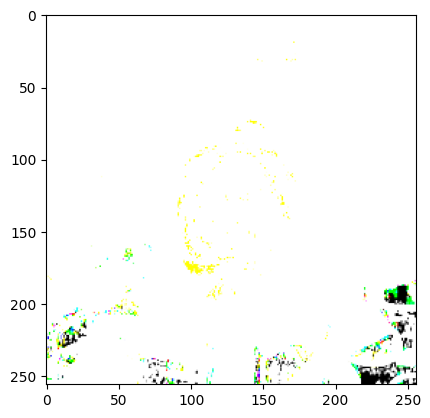

In [58]:
for i in train_ds.take(1):
    plt.imshow(i[0][0])   # clipping int값이 아닌 float 

In [59]:
labels = train_ds.class_names
labels

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

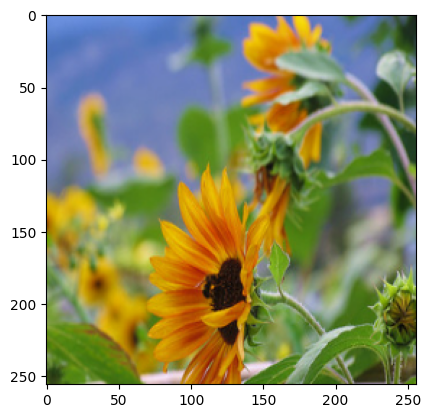

In [60]:
for i in train_ds.take(1):
    plt.imshow(i[0][0].numpy().astype('uint8'))  # float를 int로 변환

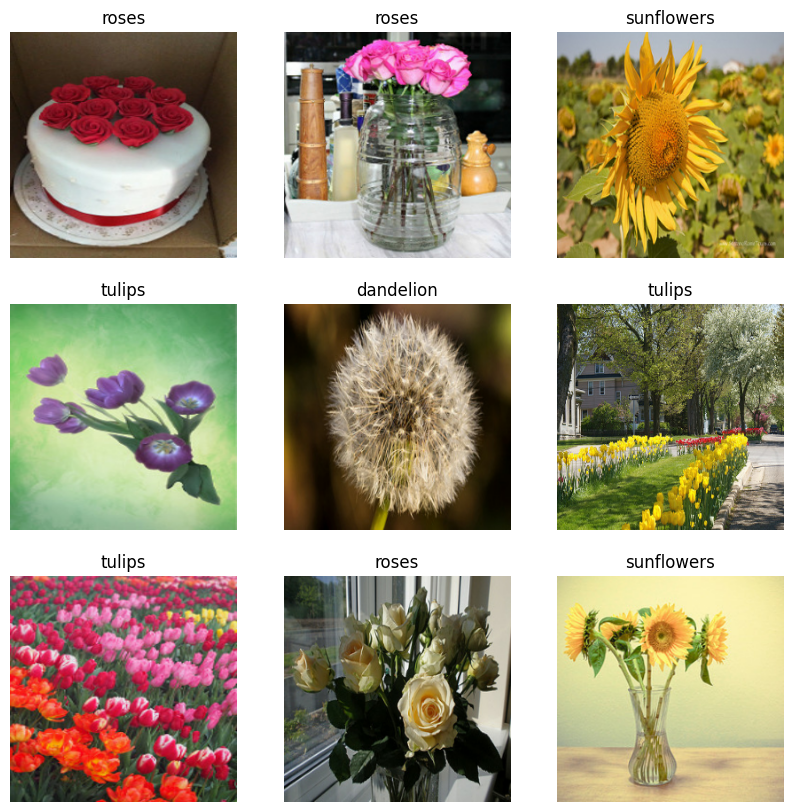

In [61]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # 32개
    for i in range(9):   # 9개를 출력
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [62]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.experimental.AUTOTUNE)
train_ds

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [63]:
tf.data.experimental.AUTOTUNE, tf.data.AUTOTUNE # -1

(-1, -1)

In [64]:
from tensorflow.keras import layers

num_classes = 5

model = tf.keras.Sequential([
  #layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(32, 3, activation='relu', input_shape=(256,256,3)),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes) # softmax 대신 compile from_logits=True 대신함 (numerical stability)
])

model.compile( optimizer='adam', loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 32)      

In [65]:
# 학습 : # CPU 약 13분 소요 , GPU RTX 3060 약 1분 소요
model.fit(train_ds,epochs=5)

Epoch 1/5
115/115 [==============================] - 20s 97ms/step - loss: 22.9811 - accuracy: 0.2613
Epoch 2/5
115/115 [==============================] - 10s 89ms/step - loss: 1.4405 - accuracy: 0.4057
Epoch 3/5
115/115 [==============================] - 10s 87ms/step - loss: 1.0488 - accuracy: 0.5967
Epoch 4/5
115/115 [==============================] - 10s 88ms/step - loss: 0.6609 - accuracy: 0.7580
Epoch 5/5
115/115 [==============================] - 10s 89ms/step - loss: 0.4095 - accuracy: 0.8559


In [ ]:
# 속도 차이 비교: 각 epoch 당 위 보다 약간씩 느림 6s <<7s 
model = tf.keras.Sequential([
  #layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(32, 3, activation='relu', input_shape=(256,256,3)),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(5) # softmax 대신 compile from_logits=True 대신함 numerical stability 
])

model.compile( optimizer='adam', loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

# CPU 약 16분 소요 , GPU 약 55초 소요
model.fit(tf.keras.preprocessing.image_dataset_from_directory(data_dir), epochs=5)

Found 3670 files belonging to 5 classes.
Epoch 1/5
115/115 [==============================] - 11s 94ms/step - loss: 14.5076 - accuracy: 0.2414
Epoch 2/5
115/115 [==============================] - 11s 94ms/step - loss: 1.4005 - accuracy: 0.4071
Epoch 3/5
115/115 [==============================] - 11s 94ms/step - loss: 1.0553 - accuracy: 0.5744
Epoch 4/5
115/115 [==============================] - 11s 96ms/step - loss: 0.7863 - accuracy: 0.6937
Epoch 5/5
115/115 [==============================] - 11s 96ms/step - loss: 0.6953 - accuracy: 0.7469


- image_size=(256,256) 으로 되어있어 이미지가 왜곡됨
- 데이터 타입까지 맞춰야함 
- 중복 이미지도 처리 해야함 
- 이미지가 작은경우 큰 이미지 사이즈로 지정한경우 패딩으로 채움

### ImageDataGenerator
- data augmentation
- 넘파이로 관리하는 방식 

In [67]:
imger=tf.keras.preprocessing.image.ImageDataGenerator( )#  Generator ,data augmentation ,크기 조정 동시에 가능
imger  # <keras.preprocessing.image.ImageDataGenerator>

In [68]:
dir(imger)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_keras_api_names',
 '_keras_api_names_v1',
 '_validation_split',
 'apply_transform',
 'brightness_range',
 'channel_axis',
 'channel_shift_range',
 'col_axis',
 'cval',
 'data_format',
 'dtype',
 'featurewise_center',
 'featurewise_std_normalization',
 'fill_mode',
 'fit',
 'flow',
 'flow_from_dataframe',
 'flow_from_directory',
 'get_random_transform',
 'height_shift_range',
 'horizontal_flip',
 'interpolation_order',
 'mean',
 'preprocessing_function',
 'random_transform',
 'rescale',
 'rotation_range',
 'row_axis',
 'samplewise_center',
 'samplewise_std_normalization',
 'shear_range',
 'standardize',
 'std',
 'vertica

In [69]:
imger.flow_from_directory(data_dir) # DirectoryIterator  포맷! -> next

Found 3670 images belonging to 5 classes.


In [70]:
next(imger.flow_from_directory(data_dir))

Found 3670 images belonging to 5 classes.


(array([[[[ 99., 137.,  36.],
          [102., 140.,  41.],
          [107., 143.,  47.],
          ...,
          [ 55.,  82.,  11.],
          [ 56.,  82.,   8.],
          [ 46.,  78.,   2.]],
 
         [[ 98., 137.,  46.],
          [103., 144.,  40.],
          [100., 135.,  41.],
          ...,
          [ 50.,  75.,   9.],
          [ 54.,  80.,   7.],
          [ 51.,  77.,   4.]],
 
         [[ 92., 130.,  43.],
          [ 99., 138.,  32.],
          [ 96., 131.,  37.],
          ...,
          [ 49.,  74.,   8.],
          [ 50.,  77.,   8.],
          [ 49.,  75.,   4.]],
 
         ...,
 
         [[ 65.,  93.,  68.],
          [ 56.,  88.,  65.],
          [ 51.,  80.,  62.],
          ...,
          [ 17.,  32.,  13.],
          [ 14.,  29.,   8.],
          [ 15.,  32.,  13.]],
 
         [[ 63.,  89.,  64.],
          [ 51.,  83.,  62.],
          [ 47.,  80.,  59.],
          ...,
          [ 17.,  31.,   8.],
          [ 15.,  30.,   7.],
          [ 17.,  35.,  11.

Numpy , Tensor 장단점을 이해해야함

##### tf.data  복습
- 학습 효율성: 오토튠으로 컴퓨터 상황에 맞추어 최적화하여 시간 단축
  - 큰 데이터에서는 하드웨어가 구축된 사람에게는 효과가 있음
  - cache().prefetch( tf.data.AUTOTUNE )
  - map으로 데이터 수정

- from_tensor_slices : 기존 넘파이 형태를 바꿈
- from_generator:  generator 함수를 사용하여 TensorFlow dataset을 만들 수 있다 기존의 넘파이로 구축된것을 쉽게 바꿈 
    - from, as :넘파이,판다스,텐서에 데이터 포맷 변경

- 데이터 구조에 따라서 steps_per_epoch - 에폭 한개당 몇개씩 처리할지 지정(내부적으로 제너레이터이기 때문)
- tf.data + ImageDataGenerator 둘다 해야함


- image_dataset_from_directory 데이터 전처리 해줘야 함
- experimental.preprocessing.Rescaling 정규화